# Grid Cell Emergence and Other Cell Types

## Grid Cell Emergence

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import time
import matplotlib.pyplot as plt
import matplotlib as mpl
import argparse
import json

from src.data.place_cells import PlaceCells
from src.data.trajectory_generator import TrajectoryGenerator
from src.model import RNN, MultilayerPCN, TemporalPCN, HierarchicalPCN
from src.trainer import Trainer, PCTrainer
from src.visualize import *
import src.utils as utils
# from pypalettes import load_cmap

import pandas as pd
import seaborn as sns

Apr-10-2025-12-30-07: tanh tpc

Apr-10-2025-11-38-15: non-sparse pcn

Apr-10-2025-11-21-07: non-relu pcn

Apr-10-2025-11-19-06: regular pcn

In [2]:
pcn_path = 'Apr-10-2025-11-19-06'
pcn_non_negative_path = 'Apr-10-2025-11-21-07'
pcn_non_sparse_path = 'Apr-10-2025-11-38-15'
tpc_path = 'Mar-24-2025-10-48-57'
tpc_sigmoid_path = 'Jun-21-2026-10-27-46'
tpc_non_negative_path = 'Apr-10-2025-12-30-07'
rnn_path = 'Apr-28-2025-12-10-16'

### Grid-cell selection by shuffled null

This replaces fixed top-N selection with model-specific grid-cell counts from a shuffled-null threshold.


In [3]:
from pathlib import Path
from types import SimpleNamespace
from src.visualize import classify_grid_cells_by_shuffled_null

NULL_KWARGS = dict(lo_res=20, n_avg=50, n_shuffles=100, percentile=95, seed=0, shuffle_chunk_size=128)
RESULT_ROOT = Path('../results')

model_runs = {
    'pcn': ('pcn', pcn_path),
    'pcn_non_negative': ('pcn', pcn_non_negative_path),
    'pcn_non_sparse': ('pcn', pcn_non_sparse_path),
    'tpc': ('tpc', tpc_path),
    'tpc_sigmoid': ('tpc', tpc_sigmoid_path),
    'tpc_non_negative': ('tpc', tpc_non_negative_path),
    'rnn': ('rnn', rnn_path),
}

def load_opts(run_dir):
    cfg = json.load(open(run_dir / 'configs.json'))
    cfg = {k: v for k, v in cfg.items() if not k.startswith('_')}
    defaults = dict(
        device='cuda' if torch.cuda.is_available() else 'cpu', Nv=2, oned=False,
        DoG=True, box_width=1.6, box_height=1.6, place_cell_rf=0.12,
        surround_scale=2, periodic=False, sequence_length=10, dt=0.02,
        batch_size=500, learning_rate=1e-4, weight_decay=1e-4,
        decay_step_size=50, decay_rate=0.9, lambda_z=0, lambda_z_init=0,
        inf_iters=20, test_inf_iters=20, inf_lr=0.01,
        out_activation='softmax', rec_activation='relu', loss='CE',
        normalize_pc='softmax', no_velocity=False, truncating=1, rf_std=0,
        place_cell_rf_prob=None, place_cell_center_seed=0, trajectory_seed=0,
        sweep=False, restore=None, env_shape='rectangle', relu_inf=True,
    )
    defaults.update(cfg)
    if defaults.get('sequence_length') is None:
        defaults['sequence_length'] = 10
    defaults['device'] = 'cuda' if torch.cuda.is_available() else 'cpu'
    return SimpleNamespace(**defaults)

class PCNGeneratorCapture:
    def __init__(self, generator):
        self.generator = generator
        self.last_pc_outputs = None
    def get_test_batch(self):
        inputs, pc_outputs, pos = self.generator.get_test_batch()
        self.last_pc_outputs = pc_outputs
        return inputs, pc_outputs, pos

class PCNAdapter(torch.nn.Module):
    def __init__(self, pcn, capture, options, chunk=1024):
        super().__init__()
        self.pcn = pcn
        self.capture = capture
        self.options = options
        self.chunk = chunk
    def g(self, inputs):
        pc = self.capture.last_pc_outputs
        b, s, np_ = pc.shape
        pc = pc.reshape(-1, np_).to(self.options.device)
        zs = []
        for start in range(0, pc.shape[0], self.chunk):
            self.pcn.inference(pc[start:start+self.chunk], self.options.inf_iters, self.options.inf_lr)
            zs.append(self.pcn.val_nodes[0].detach().clone())
        return torch.cat(zs, dim=0).reshape(b, s, self.options.Ng)

def load_for_null(model_type, run_dir):
    options = load_opts(run_dir)
    options.save_dir = str(run_dir)
    place_cells = PlaceCells(options)
    generator = TrajectoryGenerator(
        options, place_cells, environment=getattr(options, 'env_shape', 'rectangle')
    )

    if model_type == 'tpc':
        ckpt = torch.load(run_dir / 'models' / 'most_recent_model.pth', map_location=options.device)
        model = TemporalPCN(options).to(options.device)
        init_model = HierarchicalPCN(options).to(options.device)
        model.load_state_dict(ckpt['model'])
        init_model.load_state_dict(ckpt['init_model'])
        trainer = PCTrainer(options, model, init_model, generator, place_cells)
        return model, trainer, generator, options

    if model_type == 'rnn':
        ckpt = torch.load(run_dir / 'models' / 'most_recent_model.pth', map_location=options.device)
        model = RNN(options, place_cells).to(options.device)
        model.load_state_dict(ckpt)
        trainer = Trainer(options, model, generator, place_cells, restore=False)
        return model, trainer, generator, options

    ckpt_path = run_dir / 'models' / f'model{options.n_epochs}.pth'
    model = MultilayerPCN(
        [options.Ng, options.Np], options.out_activation,
        lamb=options.lambda_z_init, use_bias=False, relu_inf=options.relu_inf,
    ).to(options.device)
    model.load_state_dict(torch.load(ckpt_path, map_location=options.device))
    model.set_sparsity(0.0)
    capture = PCNGeneratorCapture(generator)
    return PCNAdapter(model, capture, options), None, capture, options

def run_or_load_grid_null(name, model_type, run_id, force=False):
    run_dir = RESULT_ROOT / model_type / run_id
    idx_path = run_dir / 'grid_cell_indices_shuffled_null.npy'
    score_path = run_dir / 'grid_scores_shuffled_null.npy'
    rm_path = run_dir / 'rate_maps_shuffled_null.npy'
    thr_path = run_dir / 'grid_null_threshold.npy'

    if idx_path.exists() and score_path.exists() and rm_path.exists() and not force:
        idx = np.load(idx_path)
        scores = np.load(score_path)
        rate_maps = np.load(rm_path)
        threshold = float(np.load(thr_path))
        print(f'Loaded {name}: {len(idx)} cells above null threshold ({run_id})')
        return idx, scores, rate_maps, threshold

    print(f'Processing {name}: {model_type}/{run_id}')
    model, trainer, generator, options = load_for_null(model_type, run_dir)
    out = classify_grid_cells_by_shuffled_null(
        model, trainer, generator, options, Ng=options.Ng, **NULL_KWARGS
    )
    idx = np.where(out['is_grid'])[0]
    idx = idx[np.argsort(out['scores'][idx])[::-1]]
    np.save(idx_path, idx)
    np.save(score_path, out['scores'])
    np.save(rm_path, out['rate_maps'])
    np.save(thr_path, np.array(out['threshold']))
    np.save(run_dir / 'grid_null_scores.npy', out['null_scores'])
    print(f'Finished {name}: threshold={out["threshold"]:.3f}, n={len(idx)}')
    return idx, out['scores'], out['rate_maps'], out['threshold']

classified = {}
for name, (model_type, run_id) in model_runs.items():
    idx, scores_all, rms_all, threshold = run_or_load_grid_null(name, model_type, run_id)
    classified[name] = dict(idx=idx, scores=scores_all, rate_maps=rms_all, threshold=threshold)

grid_cell_counts = {name: len(v['idx']) for name, v in classified.items()}
print('Grid-cell counts:', grid_cell_counts)

pcn_n_cells = grid_cell_counts['pcn']
pcn_non_negative_n_cells = grid_cell_counts['pcn_non_negative']
pcn_non_sparse_n_cells = grid_cell_counts['pcn_non_sparse']
tpc_n_cells = grid_cell_counts['tpc']
tpc_sigmoid_n_cells = grid_cell_counts['tpc_sigmoid']
tpc_non_negative_n_cells = grid_cell_counts['tpc_non_negative']
rnn_n_cells = grid_cell_counts['rnn']


Loaded pcn: 459 cells above null threshold (Apr-10-2025-11-19-06)
Loaded pcn_non_negative: 272 cells above null threshold (Apr-10-2025-11-21-07)
Loaded pcn_non_sparse: 287 cells above null threshold (Apr-10-2025-11-38-15)
Loaded tpc: 347 cells above null threshold (Mar-24-2025-10-48-57)
Loaded tpc_sigmoid: 369 cells above null threshold (Jun-21-2026-10-27-46)
Loaded tpc_non_negative: 271 cells above null threshold (Apr-10-2025-12-30-07)
Loaded rnn: 329 cells above null threshold (Apr-28-2025-12-10-16)
Grid-cell counts: {'pcn': 459, 'pcn_non_negative': 272, 'pcn_non_sparse': 287, 'tpc': 347, 'tpc_sigmoid': 369, 'tpc_non_negative': 271, 'rnn': 329}


In [5]:
pcn_idx = classified['pcn']['idx']
pcn_non_negative_idx = classified['pcn_non_negative']['idx']
pcn_non_sparse_idx = classified['pcn_non_sparse']['idx']
tpc_idx = classified['tpc']['idx']
tpc_sigmoid_idx = classified['tpc_sigmoid']['idx']
tpc_non_negative_idx = classified['tpc_non_negative']['idx']
rnn_idx = classified['rnn']['idx']

pcn_scores = classified['pcn']['scores'][pcn_idx]
pcn_non_negative_scores = classified['pcn_non_negative']['scores'][pcn_non_negative_idx]
pcn_non_sparse_scores = classified['pcn_non_sparse']['scores'][pcn_non_sparse_idx]
tpc_scores = classified['tpc']['scores'][tpc_idx]
tpc_sigmoid_scores = classified['tpc_sigmoid']['scores'][tpc_sigmoid_idx]
tpc_non_negative_scores = classified['tpc_non_negative']['scores'][tpc_non_negative_idx]
rnn_scores = classified['rnn']['scores'][rnn_idx]


In [6]:
# Statistical tests for ablation-induced grid-score reduction
# Main test uses the full population of grid scores, not only classified cells.

import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

rng = np.random.default_rng(0)

def clean_scores(x):
    x = np.asarray(x, dtype=float)
    return x[np.isfinite(x)]

def permutation_mean_diff(x, y, n_perm=10000, alternative="greater", rng=None):
    """
    One-sided permutation test for mean(x) - mean(y).
    alternative="greater" tests whether x has larger scores than y.
    """
    if rng is None:
        rng = np.random.default_rng()

    x = clean_scores(x)
    y = clean_scores(y)

    obs = x.mean() - y.mean()
    pooled = np.concatenate([x, y])
    n_x = len(x)

    null = np.empty(n_perm)
    for i in range(n_perm):
        perm = rng.permutation(pooled)
        null[i] = perm[:n_x].mean() - perm[n_x:].mean()

    if alternative == "greater":
        p = (np.sum(null >= obs) + 1) / (n_perm + 1)
    elif alternative == "less":
        p = (np.sum(null <= obs) + 1) / (n_perm + 1)
    else:
        p = (np.sum(np.abs(null) >= abs(obs)) + 1) / (n_perm + 1)

    return obs, p

def grid_fraction(key):
    return len(classified[key]["idx"]) / len(classified[key]["scores"])

comparisons = [
    ("PCN vs PCN w/o non-negativity", "pcn", "pcn_non_negative"),
    ("PCN vs PCN w/o sparsity", "pcn", "pcn_non_sparse"),
    ("tPCN vs tPCN w/o non-negativity", "tpc", "tpc_non_negative"),
]

rows = []
for label, intact_key, ablated_key in comparisons:
    intact = clean_scores(classified[intact_key]["scores"])
    ablated = clean_scores(classified[ablated_key]["scores"])

    u = mannwhitneyu(intact, ablated, alternative="greater")
    mean_diff, p_perm = permutation_mean_diff(
        intact,
        ablated,
        n_perm=10000,
        alternative="greater",
        rng=rng,
    )

    rows.append({
        "comparison": label,
        "n_intact": len(intact),
        "n_ablated": len(ablated),
        "mean_intact": intact.mean(),
        "mean_ablated": ablated.mean(),
        "mean_diff": mean_diff,
        "median_intact": np.median(intact),
        "median_ablated": np.median(ablated),
        "mannwhitney_p_one_sided": u.pvalue,
        "perm_p_mean_diff_one_sided": p_perm,
        "frac_grid_intact": grid_fraction(intact_key),
        "frac_grid_ablated": grid_fraction(ablated_key),
    })

ablation_stats = pd.DataFrame(rows)
ablation_stats

,comparison,n_intact,n_ablated,mean_intact,mean_ablated,mean_diff,median_intact,median_ablated,mannwhitney_p_one_sided,perm_p_mean_diff_one_sided,frac_grid_intact,frac_grid_ablated
0,PCN vs PCN w/o non-negativity,1024,1024,0.332921,0.153717,0.179204,0.278804,0.048372,1.014912e-37,0.0001,0.448242,0.265625
1,PCN vs PCN w/o sparsity,1024,1024,0.332921,0.215763,0.117159,0.278804,0.187267,2.585999e-12,0.0001,0.448242,0.280273
2,tPCN vs tPCN w/o non-negativity,1024,1024,0.246522,0.142124,0.104398,0.163763,0.090558,2.896186e-11,0.0001,0.338867,0.264648


In [7]:
# Same tests, restricted to cells exceeding each model's shuffled-null threshold.
# This answers a different question: among classified grid cells, are scores lower?

classified_score_arrays = {
    "pcn": pcn_scores,
    "pcn_non_negative": pcn_non_negative_scores,
    "pcn_non_sparse": pcn_non_sparse_scores,
    "tpc": tpc_scores,
    "tpc_non_negative": tpc_non_negative_scores,
}

rows = []
for label, intact_key, ablated_key in comparisons:
    intact = clean_scores(classified_score_arrays[intact_key])
    ablated = clean_scores(classified_score_arrays[ablated_key])

    u = mannwhitneyu(intact, ablated, alternative="greater")
    mean_diff, p_perm = permutation_mean_diff(
        intact,
        ablated,
        n_perm=10000,
        alternative="greater",
        rng=rng,
    )

    rows.append({
        "comparison": label,
        "n_intact_classified": len(intact),
        "n_ablated_classified": len(ablated),
        "mean_intact_classified": intact.mean(),
        "mean_ablated_classified": ablated.mean(),
        "mean_diff_classified": mean_diff,
        "mannwhitney_p_one_sided": u.pvalue,
        "perm_p_mean_diff_one_sided": p_perm,
    })

classified_ablation_stats = pd.DataFrame(rows)
classified_ablation_stats

,comparison,n_intact_classified,n_ablated_classified,mean_intact_classified,mean_ablated_classified,mean_diff_classified,mannwhitney_p_one_sided,perm_p_mean_diff_one_sided
0,PCN vs PCN w/o non-negativity,459,272,0.645791,0.509811,0.135980,3.295731e-15,0.0001
1,PCN vs PCN w/o sparsity,459,287,0.645791,0.510081,0.135711,2.846935e-14,0.0001
2,tPCN vs tPCN w/o non-negativity,347,271,0.632674,0.484698,0.147976,3.881407e-16,0.0001


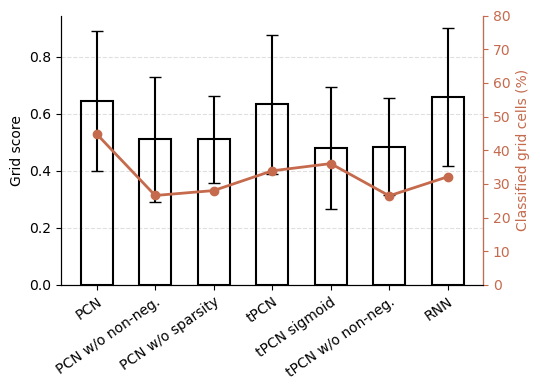

In [44]:
# Each score array contains cells exceeding that model's shuffled-null threshold.
model_keys = [
    'pcn',
    'pcn_non_negative',
    'pcn_non_sparse',
    'tpc',
    'tpc_sigmoid',
    'tpc_non_negative',
    'rnn',
]
labels = [
    'PCN',
    'PCN w/o non-neg.',
    'PCN w/o sparsity',
    'tPCN',
    'tPCN sigmoid',
    'tPCN w/o non-neg.',
    'RNN',
]
scores = [
    pcn_scores,
    pcn_non_negative_scores,
    pcn_non_sparse_scores,
    tpc_scores,
    tpc_sigmoid_scores,
    tpc_non_negative_scores,
    rnn_scores,
]

x = np.arange(len(scores))
y = np.array([s.mean() if len(s) else np.nan for s in scores])
y_err = np.array([s.std() if len(s) else np.nan for s in scores])
frac_grid = np.array([
    100 * len(classified[k]['idx']) / len(classified[k]['scores'])
    for k in model_keys
])
w = 0.55

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.spines[['top']].set_visible(False)
ax.bar(
    x,
    y,
    width=w,
    yerr=y_err,
    capsize=4,
    color='none',
    edgecolor='black',
    linewidth=1.5,
    label='Grid score',
)
ax.set_xticks(x, labels, rotation=35, ha='right', rotation_mode='anchor')
ax.set_ylabel('Grid score')
ax.set_axisbelow(True)
ax.grid(axis='y', alpha=0.4, linestyle='--')

ax2_color = '#C56A4D'
ax2 = ax.twinx()
ax2.plot(
    x,
    frac_grid,
    color=ax2_color,
    marker='o',
    lw=2,
    label='Grid cells (%)',
)
ax2.set_ylabel('Classified grid cells (%)', color=ax2_color)
ax2.tick_params(axis='y', colors=ax2_color)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_color(ax2_color)
ax2.set_ylim(0, 80)

handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
# ax.legend(handles1 + handles2, labels1 + labels2, frameon=True, loc='best')

plt.tight_layout()
plt.savefig('../results/emergence/grid_scores_shuffled_null.pdf', bbox_inches='tight')
plt.show()


In [15]:
pcn_scores.mean(), pcn_non_sparse_scores.mean(), pcn_non_negative_scores.mean(), tpc_scores.mean(), tpc_non_negative_scores.mean(), rnn_scores.mean()

(0.6457914156924272,
 0.5100808340601012,
 0.5098109817725448,
 0.6326735552508512,
 0.48469752821523654,
 0.6580077485169522)

In [31]:
tpc_rm = np.load(os.path.join("../results/tpc", tpc_path, "top64_grid_cells.npy"))[:tpc_n_cells]
tpc_sigmoid_rm = np.load(os.path.join("../results/tpc", tpc_sigmoid_path, "grid_maps.npy"))[:64]
tpc_non_negative_rm = np.load(os.path.join("../results/tpc", tpc_non_negative_path, "top64_grid_cells.npy"))[:tpc_non_negative_n_cells]

pcn_rm = np.load(os.path.join("../results/pcn", pcn_path, "grid_maps.npy"))[:pcn_n_cells]
pcn_non_negative_rm = np.load(os.path.join("../results/pcn", pcn_non_negative_path, "grid_maps.npy"))[:pcn_non_negative_n_cells]
pcn_non_sparse_rm = np.load(os.path.join("../results/pcn", pcn_non_sparse_path, "grid_maps.npy"))[:pcn_non_sparse_n_cells]

rnn_rm = np.load(os.path.join("../results/rnn", rnn_path, "top64_grid_cells.npy"))[:rnn_n_cells]

In [35]:
def plot_rms(rm, n_cells, n_cols, scores, save_name):
    n_cells = min(int(n_cells), len(rm), len(scores))
    if n_cells == 0:
        print(f"No classified grid cells to plot for {save_name}")
        return None, None

    n_cols = min(int(n_cols), n_cells)
    n_rows = int(np.ceil(n_cells / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols, n_rows), squeeze=False)

    for i, ax in enumerate(axes.flatten()):
        if i >= n_cells:
            ax.axis('off')
            continue
        r = (rm[i] - rm[i].min()) / (rm[i].max() - rm[i].min() + 1e-10)
        ax.imshow(r, cmap='jet')
        ax.axis('off')
        ax.set_title(f'{scores[i]:.2f}')

    plt.tight_layout()
    plt.savefig(f'../results/emergence/{save_name}.pdf', bbox_inches='tight')
    plt.show()
    return fig, axes


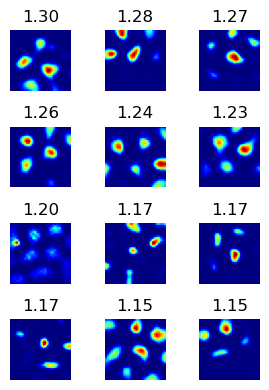

(<Figure size 300x400 with 12 Axes>,
 array([[<Axes: title={'center': '1.30'}>,
         <Axes: title={'center': '1.28'}>,
         <Axes: title={'center': '1.27'}>],
        [<Axes: title={'center': '1.26'}>,
         <Axes: title={'center': '1.24'}>,
         <Axes: title={'center': '1.23'}>],
        [<Axes: title={'center': '1.20'}>,
         <Axes: title={'center': '1.17'}>,
         <Axes: title={'center': '1.17'}>],
        [<Axes: title={'center': '1.17'}>,
         <Axes: title={'center': '1.15'}>,
         <Axes: title={'center': '1.15'}>]], dtype=object))

In [33]:
plot_rms(tpc_rm, n_cells=12, n_cols=3, scores=tpc_scores[:12], save_name='tpc_rm')

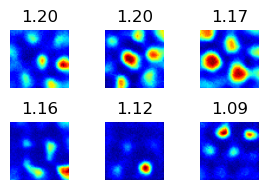

(<Figure size 300x200 with 6 Axes>,
 array([[<Axes: title={'center': '1.20'}>,
         <Axes: title={'center': '1.20'}>,
         <Axes: title={'center': '1.17'}>],
        [<Axes: title={'center': '1.16'}>,
         <Axes: title={'center': '1.12'}>,
         <Axes: title={'center': '1.09'}>]], dtype=object))

In [36]:
plot_rms(tpc_sigmoid_rm, n_cells=6, n_cols=3, scores=tpc_sigmoid_scores[:12], save_name='tpc_sigmoid_rm')

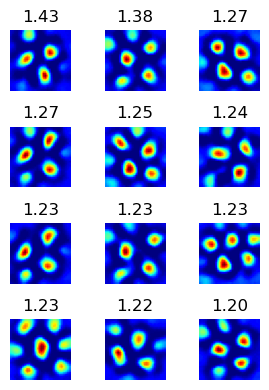

(<Figure size 300x400 with 12 Axes>,
 array([[<Axes: title={'center': '1.43'}>,
         <Axes: title={'center': '1.38'}>,
         <Axes: title={'center': '1.27'}>],
        [<Axes: title={'center': '1.27'}>,
         <Axes: title={'center': '1.25'}>,
         <Axes: title={'center': '1.24'}>],
        [<Axes: title={'center': '1.23'}>,
         <Axes: title={'center': '1.23'}>,
         <Axes: title={'center': '1.23'}>],
        [<Axes: title={'center': '1.23'}>,
         <Axes: title={'center': '1.22'}>,
         <Axes: title={'center': '1.20'}>]], dtype=object))

In [26]:
plot_rms(pcn_rm, n_cells=12, n_cols=3, scores=pcn_scores[:12], save_name='pcn_rm')

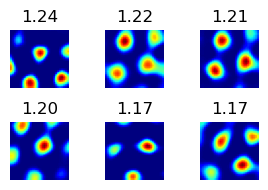

(<Figure size 300x200 with 6 Axes>,
 array([[<Axes: title={'center': '1.24'}>,
         <Axes: title={'center': '1.22'}>,
         <Axes: title={'center': '1.21'}>],
        [<Axes: title={'center': '1.20'}>,
         <Axes: title={'center': '1.17'}>,
         <Axes: title={'center': '1.17'}>]], dtype=object))

In [37]:
plot_rms(rnn_rm, n_cells=6, n_cols=3, scores=rnn_scores[:12], save_name='rnn_rm')

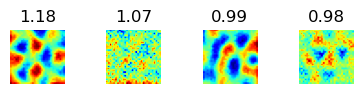

(<Figure size 400x100 with 4 Axes>,
 array([[<Axes: title={'center': '1.18'}>,
         <Axes: title={'center': '1.07'}>,
         <Axes: title={'center': '0.99'}>,
         <Axes: title={'center': '0.98'}>]], dtype=object))

In [28]:
plot_rms(tpc_non_negative_rm, n_cells=4, scores=tpc_non_negative_scores[:16], save_name='tpc_non_negative_rm', n_cols=4)

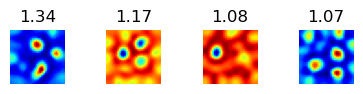

(<Figure size 400x100 with 4 Axes>,
 array([[<Axes: title={'center': '1.34'}>,
         <Axes: title={'center': '1.17'}>,
         <Axes: title={'center': '1.08'}>,
         <Axes: title={'center': '1.07'}>]], dtype=object))

In [29]:
plot_rms(pcn_non_negative_rm, n_cells=4, scores=pcn_non_negative_scores[:16], save_name='pcn_non_negative_rm', n_cols=4)

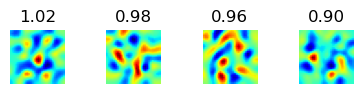

(<Figure size 400x100 with 4 Axes>,
 array([[<Axes: title={'center': '1.02'}>,
         <Axes: title={'center': '0.98'}>,
         <Axes: title={'center': '0.96'}>,
         <Axes: title={'center': '0.90'}>]], dtype=object))

In [30]:
plot_rms(pcn_non_sparse_rm, n_cells=4, scores=pcn_non_sparse_scores[:16], save_name='pcn_non_sparse_rm', n_cols=4)

## Other Cell Types Setup

Shared loading, scoring, and plotting utilities from `other_cell_types.ipynb` before the Border Cells section.

In [14]:
from pathlib import Path
from types import SimpleNamespace
import sys
import json
import math

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import ndimage

# Make imports work whether the notebook kernel starts in repo root or notebooks/.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.place_cells import PlaceCells
from src.data.trajectory_generator import TrajectoryGenerator
from src.model import TemporalPCN, HierarchicalPCN
from src.trainer import PCTrainer
from src.visualize import compute_ratemaps

RUN_ID = "Mar-24-2025-10-48-57"
MODEL = "tpc"
RUN_DIR = PROJECT_ROOT / "results" / MODEL / RUN_ID
RUN_DIR

WindowsPath('c:/Users/User/projects/place-cell-pred-coding/results/tpc/Mar-24-2025-10-48-57')

In [15]:
def load_tpc_run(run_dir):
    run_dir = Path(run_dir)
    with open(run_dir / "configs.json", "r") as f:
        cfg = json.load(f)

    cfg = {k: v for k, v in cfg.items() if not k.startswith("_get_")}

    # Backward-compatible defaults added after this old run was trained.
    cfg.setdefault("place_cell_center_seed", 0)
    cfg.setdefault("trajectory_seed", None)
    cfg.setdefault("n_module", 1)
    cfg.setdefault("module_fracs", None)
    cfg.setdefault("wr_block_diag", False)
    cfg.setdefault("wr_inter_block_scale", 0.0)
    cfg.setdefault("weight_init", "default")
    cfg.setdefault("init_gain", 1.0)
    cfg.setdefault("sweep", False)
    cfg.setdefault("restore", None)
    cfg.setdefault("save_dir", str(run_dir))
    cfg.setdefault("is_wandb", False)
    cfg.setdefault("mode", "eval")

    # Use GPU only if available; otherwise load/run on CPU.
    cfg["device"] = "cuda" if torch.cuda.is_available() else "cpu"
    cfg["save_dir"] = str(run_dir)

    options = SimpleNamespace(**cfg)

    place_cells = PlaceCells(options)
    generator = TrajectoryGenerator(options, place_cells, environment=options.env_shape)
    model = TemporalPCN(options).to(options.device)
    init_model = HierarchicalPCN(options).to(options.device)

    ckpt = torch.load(
        run_dir / "models" / "most_recent_model.pth",
        map_location=torch.device(options.device),
    )
    model.load_state_dict(ckpt["model"])
    init_model.load_state_dict(ckpt["init_model"])
    model.eval()
    init_model.eval()

    trainer = PCTrainer(options, model, init_model, generator, place_cells)
    return options, place_cells, generator, model, init_model, trainer

options, place_cells, generator, model, init_model, trainer = load_tpc_run(RUN_DIR)
print(options)

Initializing new model from scratch.
namespace(DoG=True, Ng=1024, Np=512, Nv=2, batch_size=500, box_height=1.6, box_width=1.6, decay_rate=0.9, decay_step_size=10, device='cuda', dt=0.02, env_shape='rectangle', inf_iters=10, inf_lr=0.01, is_wandb=False, lambda_z=0, lambda_z_init=0, learning_rate=0.0001, loss='CE', mode='train', n_epochs=100, n_steps=100, no_velocity=False, normalize_pc='softmax', oned=False, out_activation='softmax', periodic=False, place_cell_rf=0.12, place_cell_rf_prob=None, preloaded_data=False, rec_activation='relu', restore=None, rf_std=0, save=True, save_dir='c:\\Users\\User\\projects\\place-cell-pred-coding\\results\\tpc\\Mar-24-2025-10-48-57', save_every=100, sequence_length=10, surround_scale=2, sweep=False, test_inf_iters=20, weight_decay=0.0001, place_cell_center_seed=0, trajectory_seed=None, n_module=1, module_fracs=None, wr_block_diag=False, wr_inter_block_scale=0.0, weight_init='default', init_gain=1.0)


In [16]:
def border_score_fixed(rm, box_width, box_height=None, area_thresh_cm2=200, field_thresh=0.2):
    """
    Border score for a single 2D rate map.

    Parameters
    ----------
    rm : array, shape [res_w, res_h]
        Occupancy-normalized rate map.
    box_width, box_height : float
        Environment size in meters.
    area_thresh_cm2 : float
        Connected fields smaller than this are ignored.
    field_thresh : float
        Fraction of max activity used to define firing-field pixels.
    """
    rm = np.asarray(rm, dtype=float)
    res_w, res_h = rm.shape
    if box_height is None:
        box_height = box_width

    if not np.isfinite(rm).any() or np.nanmax(rm) <= 0:
        return np.nan, 0.0, np.nan, []

    rm = np.nan_to_num(rm, nan=0.0)
    rm_thresh = rm > (rm.max() * field_thresh)
    rm_comps, ncomps = ndimage.label(rm_thresh)

    pix_area_cm2 = (100 * box_width / res_w) * (100 * box_height / res_h)

    masks = []
    for i in range(1, ncomps + 1):
        mask = rm_comps == i
        if mask.sum() * pix_area_cm2 > area_thresh_cm2:
            masks.append(mask)

    if len(masks) == 0:
        return 0.0, 0.0, np.nan, []

    cm_max = 0.0
    for mask in masks:
        north_cov = mask[:, -1].mean()
        south_cov = mask[:, 0].mean()
        west_cov = mask[0, :].mean()
        east_cov = mask[-1, :].mean()
        cm_max = max(cm_max, north_cov, south_cov, west_cov, east_cov)

    x, y = np.mgrid[:res_w, :res_h] + 1
    d_x = np.minimum(x, res_w + 1 - x) * box_width / res_w
    d_y = np.minimum(y, res_h + 1 - y) * box_height / res_h
    dweight = np.minimum(d_x, d_y)
    dmax = min(box_width, box_height) / 2

    dms = []
    for mask in masks:
        field = rm[mask].copy()
        if field.sum() <= 0:
            continue
        field /= field.sum()
        dms.append((field * dweight[mask]).sum())

    if len(dms) == 0:
        return 0.0, cm_max, np.nan, masks

    dm = np.nanmean(dms) / dmax
    score = (cm_max - dm) / (cm_max + dm + 1e-12)
    return score, cm_max, dm, masks


def compute_border_scores_from_maps(rate_maps, options, area_thresh_cm2=200, field_thresh=0.2):
    rows = []
    for i, rm in enumerate(rate_maps):
        score, cm_max, dm, masks = border_score_fixed(
            rm,
            box_width=options.box_width,
            box_height=options.box_height,
            area_thresh_cm2=area_thresh_cm2,
            field_thresh=field_thresh
        )
        rows.append({
            "cell": i,
            "border_score": score,
            "wall_coverage": cm_max,
            "mean_wall_dist": dm,
            "n_fields": len(masks),
        })
    return rows

In [17]:
def sample_hidden_with_head_direction(
    generator,
    place_cells,
    trainer,
    options,
    n_batches=200,
    batch_size=None,
    Ng=None,
):
    if batch_size is None:
        batch_size = options.batch_size
    if Ng is None:
        Ng = options.Ng

    all_g = []
    all_hd = []
    all_pos = []

    for _ in range(n_batches):
        traj = generator.generate_trajectory(options.box_width, options.box_height, batch_size)

        v_np = np.stack(
            [
                traj["ego_v"] * np.cos(traj["target_hd"]),
                traj["ego_v"] * np.sin(traj["target_hd"]),
            ],
            axis=-1,
        )
        v = torch.tensor(v_np, dtype=torch.float32, device=options.device)

        init_pos_np = np.stack([traj["init_x"], traj["init_y"]], axis=-1)
        init_pos = torch.tensor(init_pos_np, dtype=torch.float32, device=options.device)
        init_actv = place_cells.get_activation(init_pos).squeeze(1)

        _, g = trainer.predict((v, init_actv))

        all_g.append(g[:, :, :Ng].detach().cpu().numpy().reshape(-1, Ng))
        all_hd.append(traj["target_hd"].reshape(-1))
        all_pos.append(np.stack([traj["target_x"], traj["target_y"]], axis=-1).reshape(-1, 2))

    return {
        "g": np.concatenate(all_g, axis=0),
        "hd": np.concatenate(all_hd, axis=0),
        "pos": np.concatenate(all_pos, axis=0),
    }


def compute_hd_tuning(g, hd, n_bins=36):
    g = np.asarray(g, dtype=float) # shape (n_samples, Ng)
    hd = np.asarray(hd, dtype=float)

    # Use [0, 2pi) for binning.
    hd = np.mod(hd, 2 * np.pi)
    edges = np.linspace(0, 2 * np.pi, n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    bin_idx = np.digitize(hd, edges) - 1 # shape (n_samples,)
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)

    Ng = g.shape[1]
    tuning = np.zeros((Ng, n_bins), dtype=float)
    counts = np.bincount(bin_idx, minlength=n_bins).astype(float)

    for b in range(n_bins):
        m = bin_idx == b
        if np.any(m):
            tuning[:, b] = g[m].mean(axis=0)
        else:
            tuning[:, b] = np.nan

    tuning = np.nan_to_num(tuning, nan=0.0)
    tuning_pos = tuning - tuning.min(axis=1, keepdims=True)

    z = np.exp(1j * centers)[None, :]
    denom = tuning_pos.sum(axis=1) + 1e-12
    vec = (tuning_pos * z).sum(axis=1) / denom
    hd_score = np.abs(vec)
    pref_hd = np.angle(vec)

    return {
        "tuning": tuning,
        "tuning_pos": tuning_pos,
        "hd_score": hd_score,
        "pref_hd": pref_hd,
        "bin_centers": centers,
        "bin_edges": edges,
        "occupancy": counts,
    }

In [18]:
# Shared setup: original model-cell index space

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from src.evaluation.scores import GridScorer

# Tune these if this is slow.
area_thresh_cm2 = 1500
field_thresh = 0.2

# Load saved grid-score-sorted maps and reconstruct maps in original cell order.
grid_maps = np.load(RUN_DIR / "grid_maps.npy")
unsrt_grid_scores = np.load(RUN_DIR / "unsrt_grid_scores.npy")
grid_sort_idx = np.flip(np.argsort(unsrt_grid_scores))

Ng = len(unsrt_grid_scores)

rate_maps_by_cell = np.full(
    (Ng, grid_maps.shape[1], grid_maps.shape[2]),
    np.nan,
    dtype=grid_maps.dtype,
)

rate_maps_by_cell[grid_sort_idx[:len(grid_maps)]] = grid_maps

# Recompute border scores in original cell order.
border_rows = compute_border_scores_from_maps(
    rate_maps_by_cell,
    options,
    area_thresh_cm2=area_thresh_cm2,
    field_thresh=field_thresh,
)

border_scores = np.array([r["border_score"] for r in border_rows], dtype=float)

# Tune these if this is slow. 200 batches * 500 batch_size * 10 sequence_length = 1,000,000 samples.
HD_N_BATCHES = 20
HD_BATCH_SIZE = options.batch_size
HD_N_BINS = 36

hd_samples = sample_hidden_with_head_direction(
    generator,
    place_cells,
    trainer,
    options,
    n_batches=HD_N_BATCHES,
    batch_size=HD_BATCH_SIZE,
    Ng=options.Ng,
)

hd = compute_hd_tuning(hd_samples["g"], hd_samples["hd"], n_bins=HD_N_BINS)
hd_order = np.argsort(hd["hd_score"])[::-1]

print("samples:", hd_samples["g"].shape[0])
print("Top HD scores:")
for idx in hd_order[:10]:
    print(idx, hd["hd_score"][idx], hd["pref_hd"][idx])

# Rankings, all in original model-cell index space.
grid_order = np.argsort(np.nan_to_num(unsrt_grid_scores, nan=-np.inf))[::-1]
border_order = np.argsort(np.nan_to_num(border_scores, nan=-np.inf))[::-1]
hd_order = np.argsort(np.nan_to_num(hd["hd_score"], nan=-np.inf))[::-1]

print("rate_maps_by_cell:", rate_maps_by_cell.shape)
print("grid_order[:5]:", grid_order[:5])
print("border_order[:5]:", border_order[:5])
print("hd_order[:5]:", hd_order[:5])

samples: 100000
Top HD scores:
476 0.637058991207354 1.8384892035836418
10 0.6171611343921652 1.7637964940234818
525 0.6127289834204247 0.046538446132479365
194 0.6066364951959277 2.4718962862593457
636 0.603421109439046 0.013655213108253543
407 0.6018124266567892 0.9924568124593984
417 0.6016058176352628 1.760794478210683
625 0.5996423977010217 -0.6954995478498854
882 0.5938015426173276 -0.8745152680085839
941 0.590651653043676 0.3882770461423454
rate_maps_by_cell: (1024, 50, 50)
grid_order[:5]: [915 128 952 395 962]
border_order[:5]: [387 726 719 392 294]
hd_order[:5]: [476  10 525 194 636]


c:\users\user\projects\place-cell-pred-coding\src\evaluation\scores.py:141: RuntimeWarning: invalid value encountered in power
  std_seq1 = np.power(
c:\users\user\projects\place-cell-pred-coding\src\evaluation\scores.py:148: RuntimeWarning: invalid value encountered in power
  std_seq2 = np.power(
c:\users\user\projects\place-cell-pred-coding\src\evaluation\scores.py:141: RuntimeWarning: invalid value encountered in power
  std_seq1 = np.power(
c:\users\user\projects\place-cell-pred-coding\src\evaluation\scores.py:148: RuntimeWarning: invalid value encountered in power
  std_seq2 = np.power(
c:\users\user\projects\place-cell-pred-coding\src\evaluation\scores.py:141: RuntimeWarning: invalid value encountered in power
  std_seq1 = np.power(
c:\users\user\projects\place-cell-pred-coding\src\evaluation\scores.py:148: RuntimeWarning: invalid value encountered in power
  std_seq2 = np.power(
c:\users\user\projects\place-cell-pred-coding\src\evaluation\scores.py:141: RuntimeWarning: invalid 

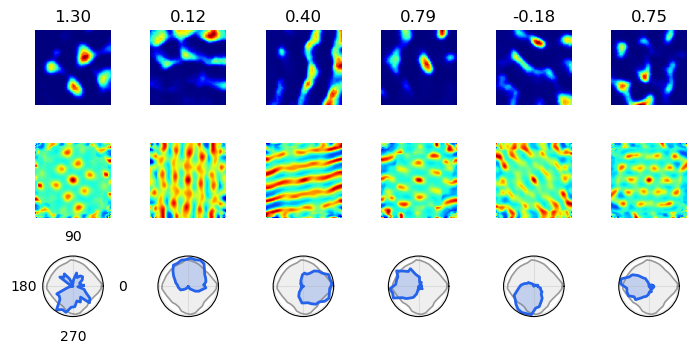

In [19]:
def plot_selected_cells_3row_panel(
    cell_indices,
    rate_maps_by_cell,
    grid_scores,
    border_scores,
    hd,
    hd_samples,
    options,
    cmap_rm="jet",
    cmap_sac="jet",
    hd_color="#2563eb",
    occ_color="gray",
):
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    from src.evaluation.scores import GridScorer

    cell_indices = np.asarray(cell_indices, dtype=int)
    n = len(cell_indices)

    res_w = rate_maps_by_cell.shape[1]
    res_h = rate_maps_by_cell.shape[2]

    coord_range = (
        (-options.box_width / 2, options.box_width / 2),
        (-options.box_height / 2, options.box_height / 2),
    )
    masks_parameters = zip([0.2] * 10, np.linspace(0.4, 1.0, num=10).tolist())
    scorer = GridScorer(res_w, res_h, coord_range, masks_parameters)

    # Overall sampled head-direction occupancy
    n_bins = len(hd["bin_centers"])
    hd_vals = np.mod(hd_samples["hd"], 2 * np.pi)
    occ_counts, _ = np.histogram(
        hd_vals,
        bins=n_bins,
        range=(0, 2 * np.pi),
    )

    occ = occ_counts.astype(float)
    if occ.max() > 0:
        occ = occ / occ.max()

    theta = hd["bin_centers"]
    theta_closed = np.r_[theta, theta[0]]
    occ_closed = np.r_[occ, occ[0]]

    nd = 1.2
    fig = plt.figure(figsize=(nd * n, 3 * nd))
    gs = fig.add_gridspec(
        3,
        n,
        height_ratios=[1.0, 1.0, 0.8],
        # hspace=0.35,
        # wspace=0.08,
    )

    axes_rm = []
    axes_sac = []
    axes_hd = []

    for col, idx in enumerate(cell_indices):
        rm = rate_maps_by_cell[idx]

        # Row 0: rate map
        ax_rm = fig.add_subplot(gs[0, col])

        if np.isfinite(rm).any():
            rm_plot = (rm - np.nanmin(rm)) / (np.nanmax(rm) - np.nanmin(rm) + 1e-12)
            ax_rm.imshow(
                rm_plot.T,
                origin="lower",
                cmap=cmap_rm,
                aspect="equal",
                vmin=0,
                vmax=1,
                # interpolation="gaussian",
            )
        else:
            ax_rm.text(0.5, 0.5, "No map", ha="center", va="center")

        ax_rm.set_title(
            # f"Cell {idx}\n"
            f"{grid_scores[idx]:.2f}",
            # f"B={border_scores[idx]:.2f}, "
            # f"HD={hd['hd_score'][idx]:.2f}",
            # fontsize=8,
        )
        ax_rm.set_xticks([])
        ax_rm.set_yticks([])
        ax_rm.axis("off")
        axes_rm.append(ax_rm)

        # Row 1: SAC
        ax_sac = fig.add_subplot(gs[1, col])

        if np.isfinite(rm).any():
            sac = scorer.calculate_sac(np.nan_to_num(rm, nan=0.0))
            ax_sac.imshow(
                sac,
                origin="lower",
                cmap=cmap_sac,
                aspect="equal",
            )
        else:
            ax_sac.text(0.5, 0.5, "No SAC", ha="center", va="center")

        ax_sac.set_xticks([])
        ax_sac.set_yticks([])
        ax_sac.axis("off")
        axes_sac.append(ax_sac)

        # Row 2: HD polar tuning over occupancy
        ax_hd = fig.add_subplot(gs[2, col], projection="polar")

        r = hd["tuning_pos"][idx].astype(float)
        if r.max() > 0:
            r = r / r.max()
        r_closed = np.r_[r, r[0]]

        ax_hd.plot(
            theta_closed,
            occ_closed,
            color=occ_color,
            lw=1.2,
            alpha=0.75,
            label="Occupancy",
        )
        ax_hd.fill(
            theta_closed,
            occ_closed,
            color=occ_color,
            alpha=0.12,
        )

        ax_hd.plot(
            theta_closed,
            r_closed,
            color=hd_color,
            lw=2.0,
            label="HD tuning",
        )
        ax_hd.fill(
            theta_closed,
            r_closed,
            color=hd_color,
            alpha=0.22,
        )

        ax_hd.set_yticklabels([])
        ax_hd.grid(alpha=0.3)
        
        axes_hd.append(ax_hd)

    for i in range(n):
        if i == 0:
            axes_hd[i].set_thetagrids(
                angles=[0, 90, 180, 270],
                labels=["0", "90", "180", "270"],
                # fontsize=7,
                rotation=0,
            )
        else:
            axes_hd[i].set_thetagrids(
                angles=[0, 90, 180, 270],
                labels=["", "", "", ""],
            )
    # axes_rm[0].set_ylabel("Rate map", fontsize=10)
    # axes_sac[0].set_ylabel("SAC", fontsize=10)
    # axes_hd[0].set_ylabel("HD", fontsize=10, labelpad=22)

    legend_handles = [
        Line2D([0], [0], color=occ_color, lw=1.5, label="Occupancy"),
        Line2D([0], [0], color=hd_color, lw=2.0, label="HD tuning"),
    ]
    # fig.legend(
    #     handles=legend_handles,
    #     loc="upper right",
    #     frameon=False,
    #     bbox_to_anchor=(0.995, 0.995),
    # )

    plt.tight_layout()
    return fig, (axes_rm, axes_sac, axes_hd)


# Example usage:
selected_cells = [915, 719, 974, 843, 587, 1016]  # original cell indices

fig, axes = plot_selected_cells_3row_panel(
    cell_indices=selected_cells,
    rate_maps_by_cell=rate_maps_by_cell,
    grid_scores=unsrt_grid_scores,
    border_scores=border_scores,
    hd=hd,
    hd_samples=hd_samples,
    options=options,
)
fig.savefig("../results/emergence/other_cell_types.pdf", bbox_inches="tight")

## Border Cells

A border-like unit should have a firing field that both:

1. Covers a large fraction of one wall.
2. Has activity close to the nearest wall.

The score is:

$$
B = \frac{C_M - D_M}{C_M + D_M}
$$

where `C_M` is maximum wall coverage and `D_M` is mean normalized distance from the nearest wall.

In [4]:
# Tune these if this is slow.
area_thresh_cm2 = 1500
field_thresh = 0.2

# Load saved grid-score-sorted maps and recover original model cell indices.
grid_maps = np.load(RUN_DIR / "grid_maps.npy")
print("grid_maps:", grid_maps.shape)
unsrt_grid_scores = np.load(RUN_DIR / "unsrt_grid_scores.npy")

grid_sort_idx = np.flip(np.argsort(unsrt_grid_scores))

# grid_maps[k] corresponds to original model cell grid_sort_idx[k]
rate_maps = grid_maps

border_rows = compute_border_scores_from_maps(
    rate_maps, options, area_thresh_cm2=area_thresh_cm2, field_thresh=field_thresh
)

for k, row in enumerate(border_rows):
    orig_cell = int(grid_sort_idx[k])
    row["grid_sorted_idx"] = int(k)
    row["cell"] = orig_cell
    row["grid_score"] = float(unsrt_grid_scores[orig_cell])

border_scores = np.array([r["border_score"] for r in border_rows], dtype=float)
border_order = np.argsort(np.nan_to_num(border_scores, nan=-np.inf))[::-1]

print("rate_maps:", rate_maps.shape)
print("Top border scores:")
for k in border_order[:10]:
    print(border_rows[k])


grid_maps: (1024, 50, 50)
rate_maps: (1024, 50, 50)
Top border scores:
{'cell': 387, 'border_score': 0.7317448513206695, 'wall_coverage': 0.66, 'mean_wall_dist': 0.10223699986323341, 'n_fields': 1, 'grid_sorted_idx': 570, 'grid_score': 0.11591037633414855}
{'cell': 726, 'border_score': 0.7274167046946755, 'wall_coverage': 0.74, 'mean_wall_dist': 0.116770688842485, 'n_fields': 1, 'grid_sorted_idx': 663, 'grid_score': 0.05280783263526276}
{'cell': 719, 'border_score': 0.660272405750135, 'wall_coverage': 0.72, 'mean_wall_dist': 0.14732755119707416, 'n_fields': 1, 'grid_sorted_idx': 562, 'grid_score': 0.12019214105700339}
{'cell': 392, 'border_score': 0.6230821284180215, 'wall_coverage': 0.72, 'mean_wall_dist': 0.16720094614245418, 'n_fields': 1, 'grid_sorted_idx': 454, 'grid_score': 0.20679521804404694}
{'cell': 294, 'border_score': 0.562608606181051, 'wall_coverage': 0.54, 'mean_wall_dist': 0.15115195943974188, 'n_fields': 1, 'grid_sorted_idx': 510, 'grid_score': 0.1679300300011522}
{'ce

(<Figure size 400x300 with 1 Axes>,
 <Axes: xlabel='Border score', ylabel='Cell count'>)

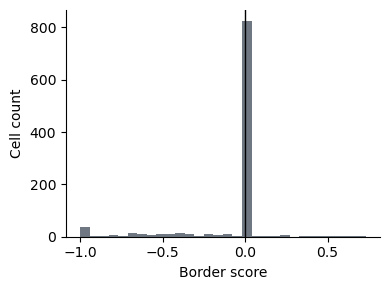

In [5]:
def plot_border_score_hist(border_scores):
    fig, ax = plt.subplots(figsize=(4, 3))
    vals = border_scores[np.isfinite(border_scores)]
    ax.hist(vals, bins=30, color="#4b5563", alpha=0.8)
    ax.axvline(0, color="black", lw=1)
    ax.set_xlabel("Border score")
    ax.set_ylabel("Cell count")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    return fig, ax

plot_border_score_hist(border_scores)

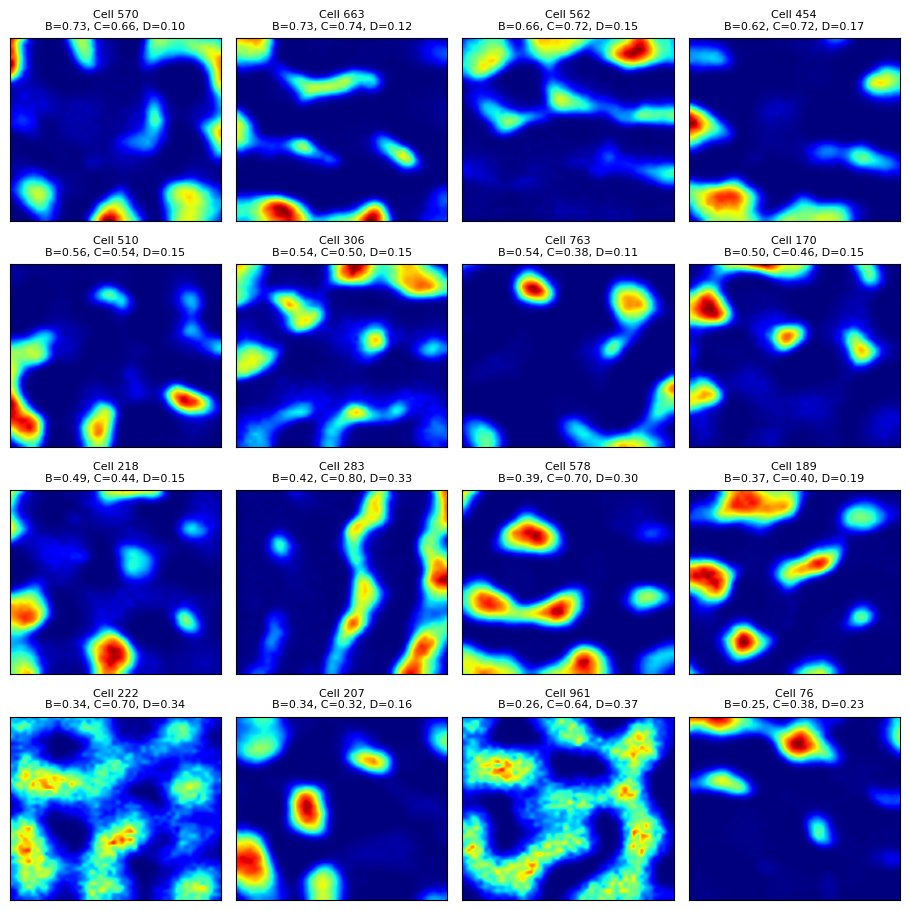

(<Figure size 920x920 with 16 Axes>,
 array([<Axes: title={'center': 'Cell 570\nB=0.73, C=0.66, D=0.10'}>,
        <Axes: title={'center': 'Cell 663\nB=0.73, C=0.74, D=0.12'}>,
        <Axes: title={'center': 'Cell 562\nB=0.66, C=0.72, D=0.15'}>,
        <Axes: title={'center': 'Cell 454\nB=0.62, C=0.72, D=0.17'}>,
        <Axes: title={'center': 'Cell 510\nB=0.56, C=0.54, D=0.15'}>,
        <Axes: title={'center': 'Cell 306\nB=0.54, C=0.50, D=0.15'}>,
        <Axes: title={'center': 'Cell 763\nB=0.54, C=0.38, D=0.11'}>,
        <Axes: title={'center': 'Cell 170\nB=0.50, C=0.46, D=0.15'}>,
        <Axes: title={'center': 'Cell 218\nB=0.49, C=0.44, D=0.15'}>,
        <Axes: title={'center': 'Cell 283\nB=0.42, C=0.80, D=0.33'}>,
        <Axes: title={'center': 'Cell 578\nB=0.39, C=0.70, D=0.30'}>,
        <Axes: title={'center': 'Cell 189\nB=0.37, C=0.40, D=0.19'}>,
        <Axes: title={'center': 'Cell 222\nB=0.34, C=0.70, D=0.34'}>,
        <Axes: title={'center': 'Cell 207\nB=0.34, C=

In [6]:
def plot_top_border_cells(rate_maps, border_rows, order, n=16, cmap="jet"):
    n = min(n, len(order))
    n_col = min(4, n)
    n_row = int(np.ceil(n / n_col))
    fig, axes = plt.subplots(n_row, n_col, figsize=(2.3 * n_col, 2.3 * n_row), squeeze=False)
    axes = axes.ravel()

    for ax, idx in zip(axes, order[:n]):
        score = border_rows[idx]["border_score"]
        cm = border_rows[idx]["wall_coverage"]
        dm = border_rows[idx]["mean_wall_dist"]
        rm = rate_maps[idx]
        rm = (rm - np.nanmin(rm)) / (np.nanmax(rm) - np.nanmin(rm) + 1e-12)
        ax.imshow(rm.T, origin="lower", cmap=cmap, aspect="auto", vmin=0, vmax=1, interpolation="gaussian")
        ax.set_title(f"Cell {idx}\nB={score:.2f}, C={cm:.2f}, D={dm:.2f}", fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    return fig, axes

plot_top_border_cells(rate_maps, border_rows, border_order, n=16)

## Head Direction Cells

The normal batch API returns positions but not head directions. The trajectory generator does create `target_hd`, so here we call `generate_trajectory(...)` directly, rebuild the same velocity input used during training, and collect hidden activations plus head direction.

For each unit, we compute a directional tuning curve and a Rayleigh/vector-length score:

$$
R = \frac{|\sum_\theta r(\theta)e^{i\theta}|}{\sum_\theta r(\theta)}
$$

High `R` means activity is concentrated around one direction.

In [7]:
def sample_hidden_with_head_direction(
    generator,
    place_cells,
    trainer,
    options,
    n_batches=200,
    batch_size=None,
    Ng=None,
):
    if batch_size is None:
        batch_size = options.batch_size
    if Ng is None:
        Ng = options.Ng

    all_g = []
    all_hd = []
    all_pos = []

    for _ in range(n_batches):
        traj = generator.generate_trajectory(options.box_width, options.box_height, batch_size)

        v_np = np.stack(
            [
                traj["ego_v"] * np.cos(traj["target_hd"]),
                traj["ego_v"] * np.sin(traj["target_hd"]),
            ],
            axis=-1,
        )
        v = torch.tensor(v_np, dtype=torch.float32, device=options.device)

        init_pos_np = np.stack([traj["init_x"], traj["init_y"]], axis=-1)
        init_pos = torch.tensor(init_pos_np, dtype=torch.float32, device=options.device)
        init_actv = place_cells.get_activation(init_pos).squeeze(1)

        _, g = trainer.predict((v, init_actv))

        all_g.append(g[:, :, :Ng].detach().cpu().numpy().reshape(-1, Ng))
        all_hd.append(traj["target_hd"].reshape(-1))
        all_pos.append(np.stack([traj["target_x"], traj["target_y"]], axis=-1).reshape(-1, 2))

    return {
        "g": np.concatenate(all_g, axis=0),
        "hd": np.concatenate(all_hd, axis=0),
        "pos": np.concatenate(all_pos, axis=0),
    }


def compute_hd_tuning(g, hd, n_bins=36):
    g = np.asarray(g, dtype=float) # shape (n_samples, Ng)
    hd = np.asarray(hd, dtype=float)

    # Use [0, 2pi) for binning.
    hd = np.mod(hd, 2 * np.pi)
    edges = np.linspace(0, 2 * np.pi, n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    bin_idx = np.digitize(hd, edges) - 1 # shape (n_samples,)
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)

    Ng = g.shape[1]
    tuning = np.zeros((Ng, n_bins), dtype=float)
    counts = np.bincount(bin_idx, minlength=n_bins).astype(float)

    for b in range(n_bins):
        m = bin_idx == b
        if np.any(m):
            tuning[:, b] = g[m].mean(axis=0)
        else:
            tuning[:, b] = np.nan

    tuning = np.nan_to_num(tuning, nan=0.0)
    tuning_pos = tuning - tuning.min(axis=1, keepdims=True)

    z = np.exp(1j * centers)[None, :]
    denom = tuning_pos.sum(axis=1) + 1e-12
    vec = (tuning_pos * z).sum(axis=1) / denom
    hd_score = np.abs(vec)
    pref_hd = np.angle(vec)

    return {
        "tuning": tuning,
        "tuning_pos": tuning_pos,
        "hd_score": hd_score,
        "pref_hd": pref_hd,
        "bin_centers": centers,
        "bin_edges": edges,
        "occupancy": counts,
    }

In [8]:
# Tune these if this is slow. 200 batches * 500 batch_size * 10 sequence_length = 1,000,000 samples.
HD_N_BATCHES = 20
HD_BATCH_SIZE = options.batch_size
HD_N_BINS = 36

hd_samples = sample_hidden_with_head_direction(
    generator,
    place_cells,
    trainer,
    options,
    n_batches=HD_N_BATCHES,
    batch_size=HD_BATCH_SIZE,
    Ng=options.Ng,
)

hd = compute_hd_tuning(hd_samples["g"], hd_samples["hd"], n_bins=HD_N_BINS)
hd_order = np.argsort(hd["hd_score"])[::-1]

print("samples:", hd_samples["g"].shape[0])
print("Top HD scores:")
for idx in hd_order[:10]:
    print(idx, hd["hd_score"][idx], hd["pref_hd"][idx])

samples: 100000
Top HD scores:
968 0.6437135775030283 -0.13470867917066912
941 0.6152413790002526 0.3970221969644051
1016 0.6115151392651783 -3.0013164914274753
636 0.6100631033885373 0.0385405448479232
149 0.6039843347858332 -1.882815957194858
432 0.5963810212464717 -1.5629781883193015
918 0.596192068185457 -1.6436599731437223
10 0.5953360245324669 1.7253481797744497
363 0.5928703139071668 -2.024203760314725
992 0.5922035062667721 2.2410514963924917


In [9]:
hd['occupancy']

array([3086., 2885., 2783., 2660., 2506., 2638., 2634., 2869., 3002.,
       2954., 2910., 2629., 2636., 2618., 2592., 2556., 2813., 2998.,
       3012., 3033., 2694., 2588., 2554., 2618., 2618., 2860., 3013.,
       3081., 2926., 2845., 2673., 2668., 2657., 2665., 2729., 2997.])

(<Figure size 400x300 with 1 Axes>,
 <Axes: xlabel='Head-direction score / vector length', ylabel='Cell count'>)

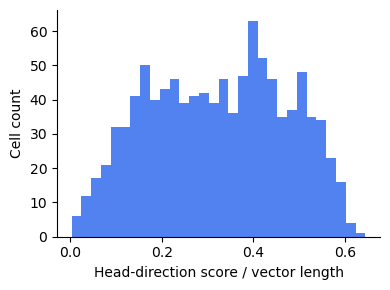

In [10]:
def plot_hd_score_hist(hd_score):
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.hist(hd_score[np.isfinite(hd_score)], bins=30, color="#2563eb", alpha=0.8)
    ax.set_xlabel("Head-direction score / vector length")
    ax.set_ylabel("Cell count")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    return fig, ax

plot_hd_score_hist(hd["hd_score"])

(<Figure size 960x720 with 12 Axes>,
 array([<PolarAxes: title={'center': 'Cell 968\nR=0.64'}>,
        <PolarAxes: title={'center': 'Cell 941\nR=0.62'}>,
        <PolarAxes: title={'center': 'Cell 1016\nR=0.61'}>,
        <PolarAxes: title={'center': 'Cell 636\nR=0.61'}>,
        <PolarAxes: title={'center': 'Cell 149\nR=0.60'}>,
        <PolarAxes: title={'center': 'Cell 432\nR=0.60'}>,
        <PolarAxes: title={'center': 'Cell 918\nR=0.60'}>,
        <PolarAxes: title={'center': 'Cell 10\nR=0.60'}>,
        <PolarAxes: title={'center': 'Cell 363\nR=0.59'}>,
        <PolarAxes: title={'center': 'Cell 992\nR=0.59'}>,
        <PolarAxes: title={'center': 'Cell 142\nR=0.59'}>,
        <PolarAxes: title={'center': 'Cell 194\nR=0.59'}>], dtype=object))

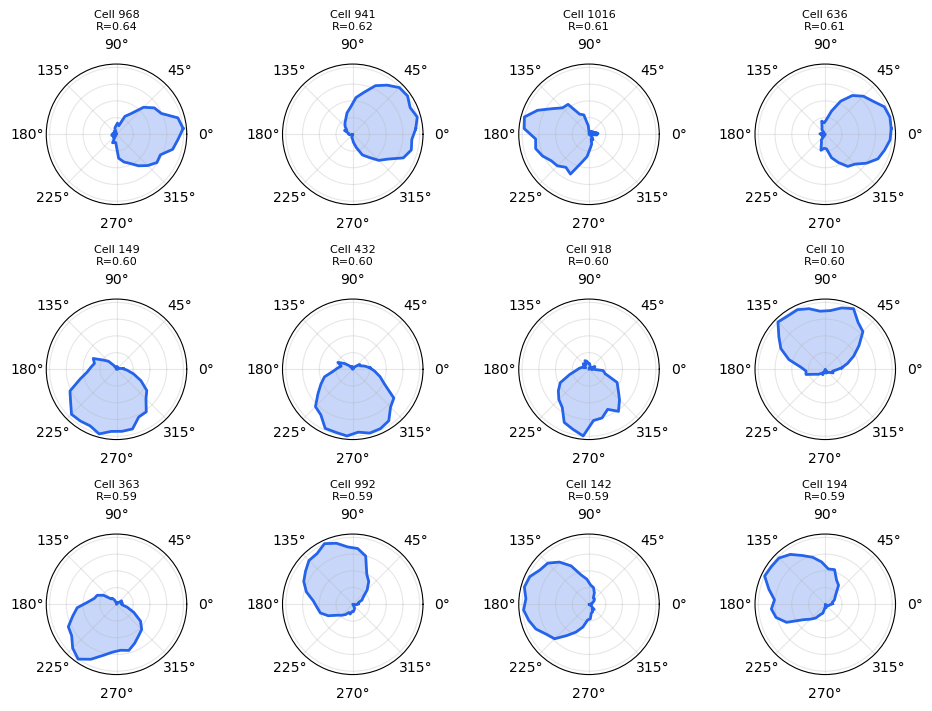

In [11]:
def plot_top_hd_cells(hd, order, n=12, color="#2563eb"):
    n = min(n, len(order))
    n_col = min(4, n)
    n_row = int(np.ceil(n / n_col))
    fig, axes = plt.subplots(
        n_row,
        n_col,
        figsize=(2.4 * n_col, 2.4 * n_row),
        subplot_kw={"projection": "polar"},
        squeeze=False,
    )
    axes = axes.ravel()

    theta = hd["bin_centers"]
    theta_closed = np.r_[theta, theta[0]]

    for ax, idx in zip(axes, order[:n]):
        r = hd["tuning_pos"][idx]
        if r.max() > 0:
            r = r / r.max()
        r_closed = np.r_[r, r[0]]

        ax.plot(theta_closed, r_closed, color=color, lw=2)
        ax.fill(theta_closed, r_closed, color=color, alpha=0.25)
        ax.set_title(f"Cell {idx}\nR={hd['hd_score'][idx]:.2f}", fontsize=8)
        ax.set_yticklabels([])
        ax.grid(alpha=0.3)

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    return fig, axes

plot_top_hd_cells(hd, hd_order, n=12)

(<Figure size 960x720 with 12 Axes>,
 array([<PolarAxes: title={'center': 'Cell 968\nR=0.64'}>,
        <PolarAxes: title={'center': 'Cell 941\nR=0.62'}>,
        <PolarAxes: title={'center': 'Cell 1016\nR=0.61'}>,
        <PolarAxes: title={'center': 'Cell 636\nR=0.61'}>,
        <PolarAxes: title={'center': 'Cell 149\nR=0.60'}>,
        <PolarAxes: title={'center': 'Cell 432\nR=0.60'}>,
        <PolarAxes: title={'center': 'Cell 918\nR=0.60'}>,
        <PolarAxes: title={'center': 'Cell 10\nR=0.60'}>,
        <PolarAxes: title={'center': 'Cell 363\nR=0.59'}>,
        <PolarAxes: title={'center': 'Cell 992\nR=0.59'}>,
        <PolarAxes: title={'center': 'Cell 142\nR=0.59'}>,
        <PolarAxes: title={'center': 'Cell 194\nR=0.59'}>], dtype=object))

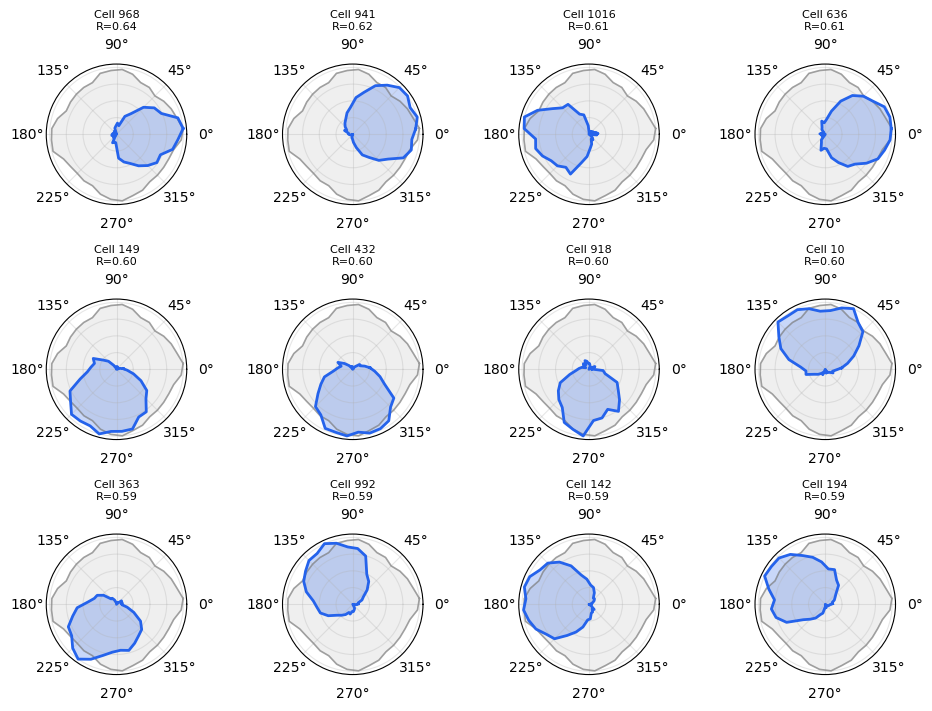

In [12]:
# Optional: overlay occupancy on each HD polar tuning plot

def plot_top_hd_cells_with_occupancy(hd, hd_samples, order, n=12, color="#2563eb"):
    import numpy as np
    import matplotlib.pyplot as plt

    hd_vals = np.mod(hd_samples["hd"], 2 * np.pi)
    occ_counts, occ_edges = np.histogram(
        hd_vals,
        bins=len(hd["bin_centers"]),
        range=(0, 2 * np.pi),
    )
    occ = occ_counts / occ_counts.max()

    n = min(n, len(order))
    n_col = min(4, n)
    n_row = int(np.ceil(n / n_col))

    fig, axes = plt.subplots(
        n_row,
        n_col,
        figsize=(2.4 * n_col, 2.4 * n_row),
        subplot_kw={"projection": "polar"},
        squeeze=False,
    )
    axes = axes.ravel()

    theta = hd["bin_centers"]
    theta_closed = np.r_[theta, theta[0]]
    occ_closed = np.r_[occ, occ[0]]

    for ax, idx in zip(axes, order[:n]):
        r = hd["tuning_pos"][idx]
        if r.max() > 0:
            r = r / r.max()
        r_closed = np.r_[r, r[0]]

        ax.plot(theta_closed, occ_closed, color="gray", lw=1.2, alpha=0.7, label="occupancy")
        ax.fill(theta_closed, occ_closed, color="gray", alpha=0.12)

        ax.plot(theta_closed, r_closed, color=color, lw=2, label="cell")
        ax.fill(theta_closed, r_closed, color=color, alpha=0.25)

        ax.set_title(f"Cell {idx}\nR={hd['hd_score'][idx]:.2f}", fontsize=8)
        ax.set_yticklabels([])
        ax.grid(alpha=0.3)

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    return fig, axes


plot_top_hd_cells_with_occupancy(hd, hd_samples, hd_order, n=12)

1024 1024


(<Figure size 960x720 with 12 Axes>,
 array([<PolarAxes: title={'center': 'Grid cell 915\ngrid=1.30, HD R=0.22'}>,
        <PolarAxes: title={'center': 'Grid cell 128\ngrid=1.27, HD R=0.16'}>,
        <PolarAxes: title={'center': 'Grid cell 952\ngrid=1.27, HD R=0.32'}>,
        <PolarAxes: title={'center': 'Grid cell 395\ngrid=1.25, HD R=0.37'}>,
        <PolarAxes: title={'center': 'Grid cell 962\ngrid=1.24, HD R=0.22'}>,
        <PolarAxes: title={'center': 'Grid cell 25\ngrid=1.23, HD R=0.32'}>,
        <PolarAxes: title={'center': 'Grid cell 13\ngrid=1.19, HD R=0.17'}>,
        <PolarAxes: title={'center': 'Grid cell 977\ngrid=1.18, HD R=0.08'}>,
        <PolarAxes: title={'center': 'Grid cell 946\ngrid=1.17, HD R=0.01'}>,
        <PolarAxes: title={'center': 'Grid cell 311\ngrid=1.16, HD R=0.25'}>,
        <PolarAxes: title={'center': 'Grid cell 883\ngrid=1.16, HD R=0.11'}>,
        <PolarAxes: title={'center': 'Grid cell 277\ngrid=1.15, HD R=0.20'}>],
       dtype=object))

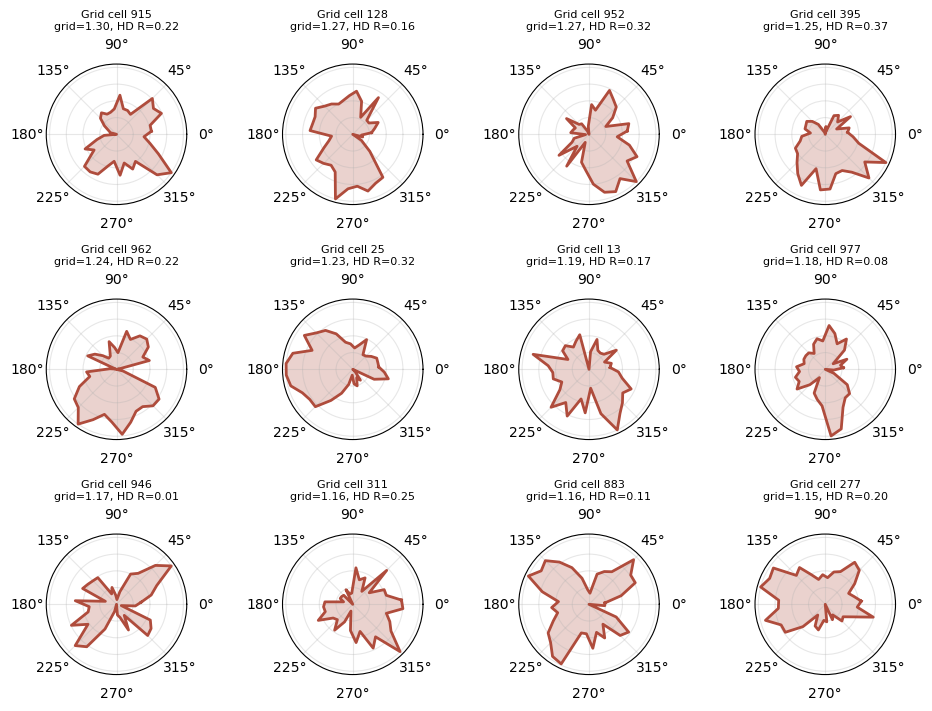

In [13]:
# 1. Polar plots for a few high-grid-score cells as comparison

unsrt_grid_scores = np.load(RUN_DIR / "unsrt_grid_scores.npy")
grid_sort_idx = np.flip(np.argsort(unsrt_grid_scores))
print(len(unsrt_grid_scores), len(grid_sort_idx))

# Original model cell indices of top grid-score cells
grid_cell_indices = grid_sort_idx[:12]

def plot_hd_tuning_for_indices(hd, indices, color="#af4c3c"):
    import numpy as np
    import matplotlib.pyplot as plt

    indices = np.asarray(indices, dtype=int)
    n = len(indices)
    n_col = min(4, n)
    n_row = int(np.ceil(n / n_col))

    fig, axes = plt.subplots(
        n_row,
        n_col,
        figsize=(2.4 * n_col, 2.4 * n_row),
        subplot_kw={"projection": "polar"},
        squeeze=False,
    )
    axes = axes.ravel()

    theta = hd["bin_centers"]
    theta_closed = np.r_[theta, theta[0]]

    for ax, idx in zip(axes, indices):
        r = hd["tuning_pos"][idx]
        if r.max() > 0:
            r = r / r.max()
        r_closed = np.r_[r, r[0]]

        ax.plot(theta_closed, r_closed, color=color, lw=2)
        ax.fill(theta_closed, r_closed, color=color, alpha=0.25)
        ax.set_title(
            f"Grid cell {idx}\n"
            f"grid={unsrt_grid_scores[idx]:.2f}, HD R={hd['hd_score'][idx]:.2f}",
            fontsize=8,
        )
        ax.set_yticklabels([])
        ax.grid(alpha=0.3)

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    return fig, axes


plot_hd_tuning_for_indices(hd, grid_cell_indices)

c:\Users\User\projects\place-cell-pred-coding\src\evaluation\scores.py:141: RuntimeWarning: invalid value encountered in power
  std_seq1 = np.power(
c:\Users\User\projects\place-cell-pred-coding\src\evaluation\scores.py:148: RuntimeWarning: invalid value encountered in power
  std_seq2 = np.power(


(<Figure size 450x1760 with 16 Axes>,
 array([[<Axes: title={'center': 'Cell 968 rate map\nHD R=0.64'}>,
         <Axes: title={'center': 'SAC'}>],
        [<Axes: title={'center': 'Cell 941 rate map\nHD R=0.62'}>,
         <Axes: title={'center': 'SAC'}>],
        [<Axes: title={'center': 'Cell 1016 rate map\nHD R=0.61'}>,
         <Axes: title={'center': 'SAC'}>],
        [<Axes: title={'center': 'Cell 636 rate map\nHD R=0.61'}>,
         <Axes: title={'center': 'SAC'}>],
        [<Axes: title={'center': 'Cell 149 rate map\nHD R=0.60'}>,
         <Axes: title={'center': 'SAC'}>],
        [<Axes: title={'center': 'Cell 432 rate map\nHD R=0.60'}>,
         <Axes: title={'center': 'SAC'}>],
        [<Axes: title={'center': 'Cell 918 rate map\nHD R=0.60'}>,
         <Axes: title={'center': 'SAC'}>],
        [<Axes: title={'center': 'Cell 10 rate map\nHD R=0.60'}>,
         <Axes: title={'center': 'SAC'}>]], dtype=object))

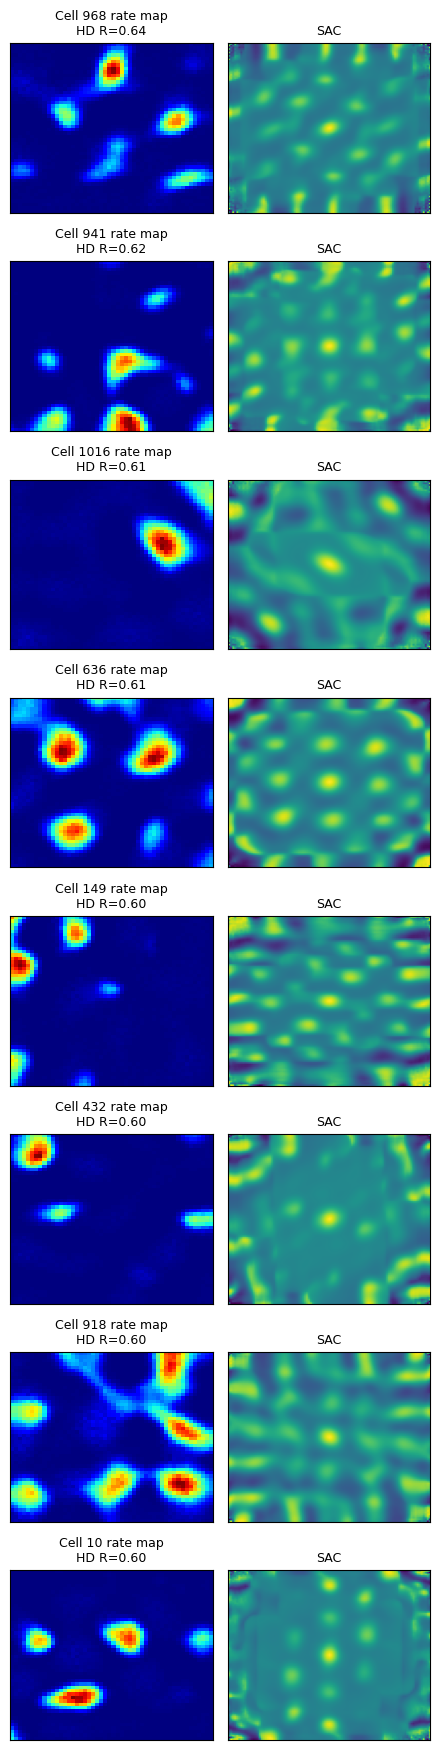

In [14]:
# 2. Plot rate map + SAC for selected HD cells

from src.evaluation.scores import GridScorer

# If you loaded grid_maps.npy, it is sorted by grid score.
# This reconstructs original model-cell order.
grid_maps = np.load(RUN_DIR / "grid_maps.npy")
unsrt_grid_scores = np.load(RUN_DIR / "unsrt_grid_scores.npy")
grid_sort_idx = np.flip(np.argsort(unsrt_grid_scores))

rate_maps_by_cell = np.empty_like(grid_maps)
rate_maps_by_cell[grid_sort_idx[:len(grid_maps)]] = grid_maps

def plot_rate_map_and_sac_for_indices(
    rate_maps_by_cell,
    indices,
    options,
    res=None,
    cmap_rm="jet",
    cmap_sac="viridis",
):
    import numpy as np
    import matplotlib.pyplot as plt

    if res is None:
        res = rate_maps_by_cell.shape[1]

    scaler = options.box_height / options.box_width
    res_w = rate_maps_by_cell.shape[1]
    res_h = rate_maps_by_cell.shape[2]

    coord_range = (
        (-options.box_width / 2, options.box_width / 2),
        (-options.box_height / 2, options.box_height / 2),
    )
    masks_parameters = zip([0.2] * 10, np.linspace(0.4, 1.0, num=10).tolist())
    scorer = GridScorer(res_w, res_h, coord_range, masks_parameters)

    indices = np.asarray(indices, dtype=int)
    n = len(indices)

    fig, axes = plt.subplots(
        n,
        2,
        figsize=(4.5, 2.2 * n),
        squeeze=False,
    )

    for row, idx in enumerate(indices):
        rm = rate_maps_by_cell[idx]
        sac = scorer.calculate_sac(rm)

        axes[row, 0].imshow(rm.T, origin="lower", cmap=cmap_rm, aspect="auto")
        axes[row, 0].set_title(
            f"Cell {idx} rate map\nHD R={hd['hd_score'][idx]:.2f}",
            fontsize=9,
        )
        axes[row, 0].set_xticks([])
        axes[row, 0].set_yticks([])

        axes[row, 1].imshow(sac, origin="lower", cmap=cmap_sac, aspect="auto")
        axes[row, 1].set_title("SAC", fontsize=9)
        axes[row, 1].set_xticks([])
        axes[row, 1].set_yticks([])

    plt.tight_layout()
    return fig, axes


hd_cell_indices = hd_order[:8]

plot_rate_map_and_sac_for_indices(
    grid_maps,
    hd_cell_indices,
    options,
)

NameError: name 'area_thresh_cm2' is not defined

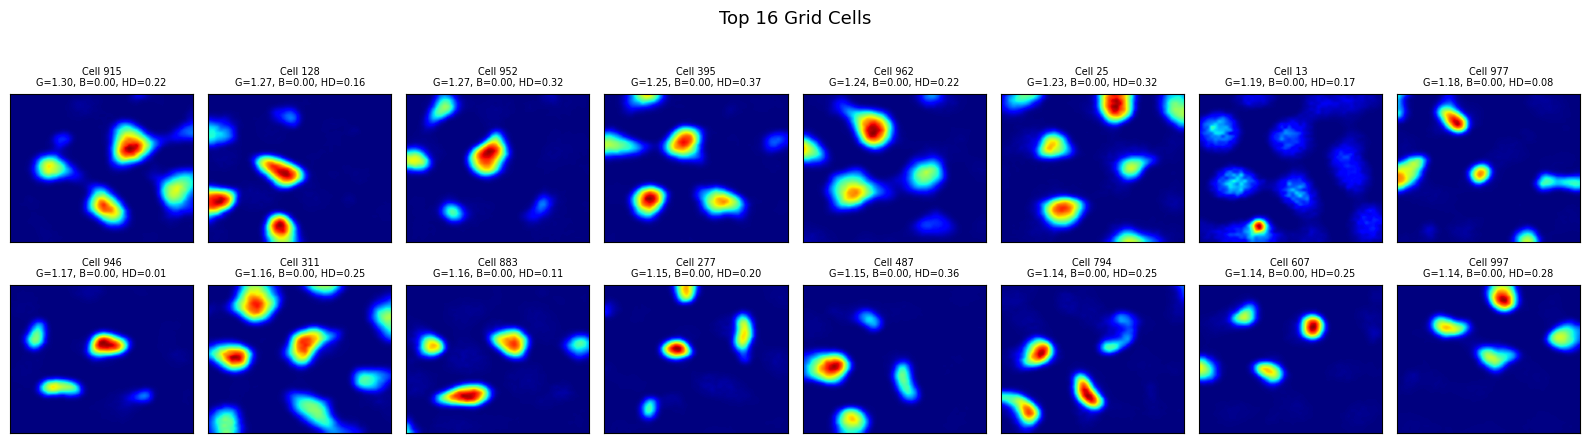

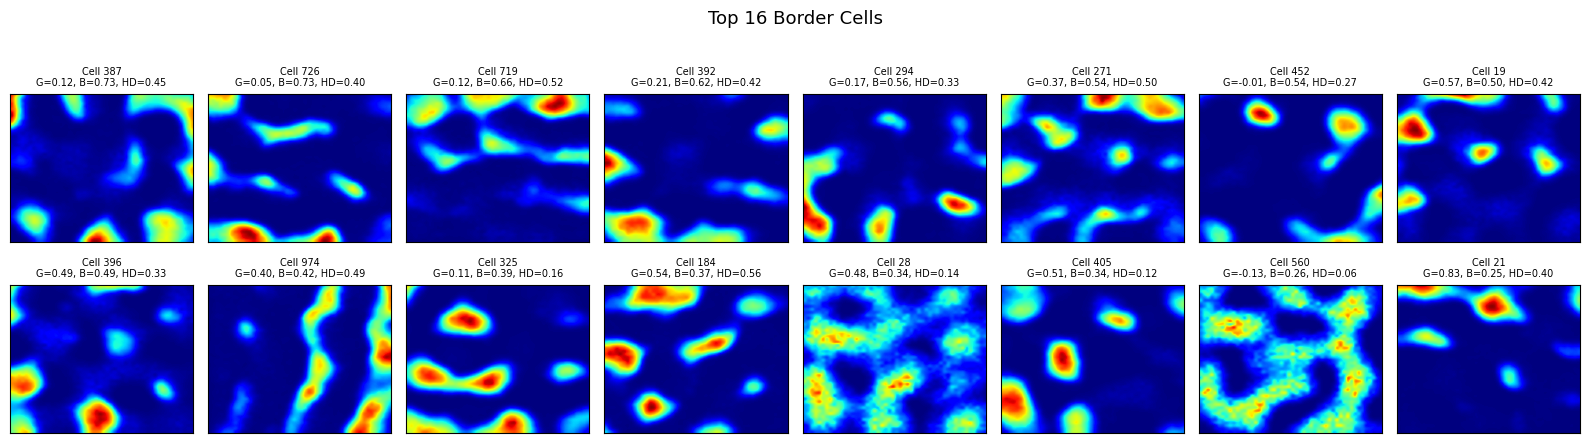

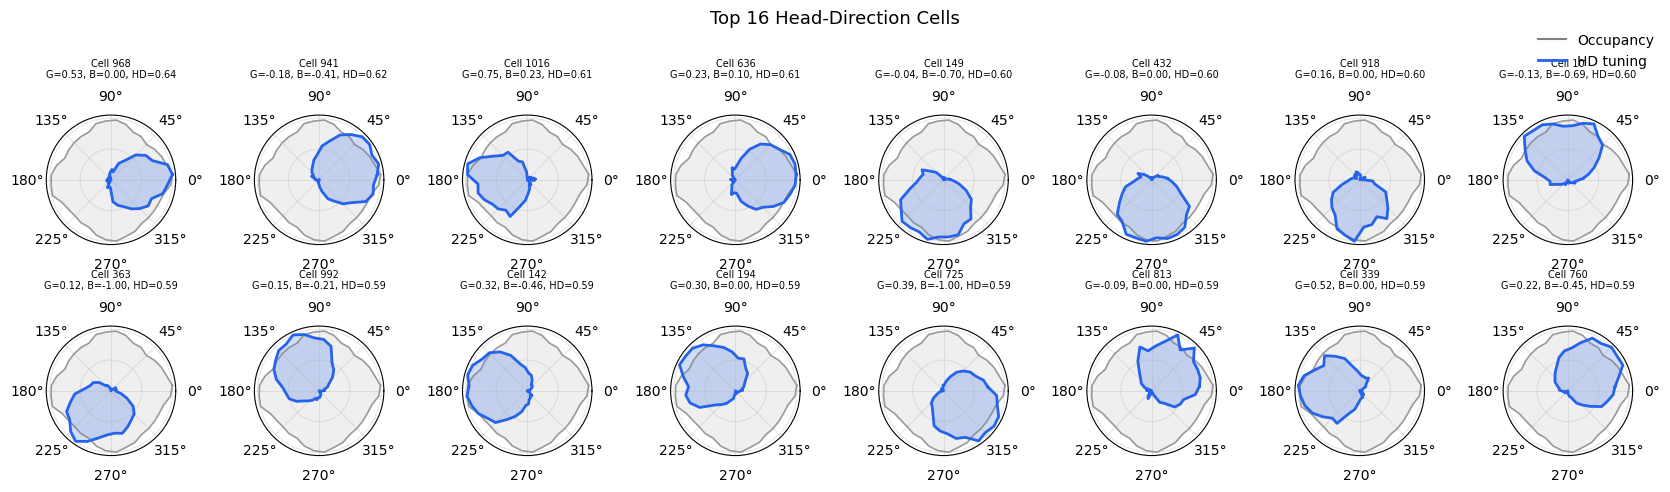

In [16]:
def plot_top_grid_cells(
    rate_maps_by_cell,
    grid_scores,
    border_scores,
    hd,
    grid_order,
    k=16,
    cmap="jet",
):
    import numpy as np
    import matplotlib.pyplot as plt

    indices = np.asarray(grid_order[:k], dtype=int)
    n_col = min(8, k)
    n_row = int(np.ceil(k / n_col))

    fig, axes = plt.subplots(
        n_row,
        n_col,
        figsize=(2.0 * n_col, 2.15 * n_row),
        squeeze=False,
    )
    axes = axes.ravel()

    for ax, idx in zip(axes, indices):
        rm = rate_maps_by_cell[idx]

        if np.isfinite(rm).any():
            rm_plot = (rm - np.nanmin(rm)) / (np.nanmax(rm) - np.nanmin(rm) + 1e-12)
            ax.imshow(
                rm_plot.T,
                origin="lower",
                cmap=cmap,
                aspect="auto",
                vmin=0,
                vmax=1,
                interpolation="gaussian",
            )
        else:
            ax.text(0.5, 0.5, "No map", ha="center", va="center")

        ax.set_title(
            f"Cell {idx}\n"
            f"G={grid_scores[idx]:.2f}, B={border_scores[idx]:.2f}, HD={hd['hd_score'][idx]:.2f}",
            fontsize=7,
        )
        ax.set_xticks([])
        ax.set_yticks([])

    for ax in axes[len(indices):]:
        ax.axis("off")

    fig.suptitle(f"Top {k} Grid Cells", y=1.02, fontsize=13)
    plt.tight_layout()
    return fig, axes


def plot_top_border_cells_unified(
    rate_maps_by_cell,
    grid_scores,
    border_scores,
    hd,
    border_order,
    k=16,
    cmap="jet",
):
    import numpy as np
    import matplotlib.pyplot as plt

    indices = np.asarray(border_order[:k], dtype=int)
    n_col = min(8, k)
    n_row = int(np.ceil(k / n_col))

    fig, axes = plt.subplots(
        n_row,
        n_col,
        figsize=(2.0 * n_col, 2.15 * n_row),
        squeeze=False,
    )
    axes = axes.ravel()

    for ax, idx in zip(axes, indices):
        rm = rate_maps_by_cell[idx]

        if np.isfinite(rm).any():
            rm_plot = (rm - np.nanmin(rm)) / (np.nanmax(rm) - np.nanmin(rm) + 1e-12)
            ax.imshow(
                rm_plot.T,
                origin="lower",
                cmap=cmap,
                aspect="auto",
                vmin=0,
                vmax=1,
                interpolation="gaussian",
            )
        else:
            ax.text(0.5, 0.5, "No map", ha="center", va="center")

        ax.set_title(
            f"Cell {idx}\n"
            f"G={grid_scores[idx]:.2f}, B={border_scores[idx]:.2f}, HD={hd['hd_score'][idx]:.2f}",
            fontsize=7,
        )
        ax.set_xticks([])
        ax.set_yticks([])

    for ax in axes[len(indices):]:
        ax.axis("off")

    fig.suptitle(f"Top {k} Border Cells", y=1.02, fontsize=13)
    plt.tight_layout()
    return fig, axes


def plot_top_hd_cells_unified(
    hd,
    hd_samples,
    grid_scores,
    border_scores,
    hd_order,
    k=16,
    hd_color="#2563eb",
    occ_color="gray",
):
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D

    indices = np.asarray(hd_order[:k], dtype=int)
    n_col = min(8, k)
    n_row = int(np.ceil(k / n_col))

    n_bins = len(hd["bin_centers"])
    hd_vals = np.mod(hd_samples["hd"], 2 * np.pi)
    occ_counts, _ = np.histogram(
        hd_vals,
        bins=n_bins,
        range=(0, 2 * np.pi),
    )
    occ = occ_counts.astype(float)
    if occ.max() > 0:
        occ = occ / occ.max()

    theta = hd["bin_centers"]
    theta_closed = np.r_[theta, theta[0]]
    occ_closed = np.r_[occ, occ[0]]

    fig, axes = plt.subplots(
        n_row,
        n_col,
        figsize=(2.1 * n_col, 2.35 * n_row),
        subplot_kw={"projection": "polar"},
        squeeze=False,
    )
    axes = axes.ravel()

    for ax, idx in zip(axes, indices):
        r = hd["tuning_pos"][idx].astype(float)
        if r.max() > 0:
            r = r / r.max()
        r_closed = np.r_[r, r[0]]

        ax.plot(
            theta_closed,
            occ_closed,
            color=occ_color,
            lw=1.2,
            alpha=0.75,
        )
        ax.fill(
            theta_closed,
            occ_closed,
            color=occ_color,
            alpha=0.12,
        )

        ax.plot(
            theta_closed,
            r_closed,
            color=hd_color,
            lw=2.0,
        )
        ax.fill(
            theta_closed,
            r_closed,
            color=hd_color,
            alpha=0.22,
        )

        ax.set_title(
            f"Cell {idx}\n"
            f"G={grid_scores[idx]:.2f}, B={border_scores[idx]:.2f}, HD={hd['hd_score'][idx]:.2f}",
            fontsize=7,
            pad=8,
        )
        ax.set_yticklabels([])
        ax.grid(alpha=0.3)

    for ax in axes[len(indices):]:
        ax.axis("off")

    legend_handles = [
        Line2D([0], [0], color=occ_color, lw=1.5, label="Occupancy"),
        Line2D([0], [0], color=hd_color, lw=2.0, label="HD tuning"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper right",
        frameon=False,
        bbox_to_anchor=(0.995, 0.995),
    )

    fig.suptitle(f"Top {k} Head-Direction Cells", y=1.02, fontsize=13)
    plt.tight_layout()
    return fig, axes


k = 16

fig_grid, axes_grid = plot_top_grid_cells(
    rate_maps_by_cell=rate_maps_by_cell,
    grid_scores=unsrt_grid_scores,
    border_scores=border_scores,
    hd=hd,
    grid_order=grid_order,
    k=k,
)

fig_border, axes_border = plot_top_border_cells_unified(
    rate_maps_by_cell=rate_maps_by_cell,
    grid_scores=unsrt_grid_scores,
    border_scores=border_scores,
    hd=hd,
    border_order=border_order,
    k=k,
)

fig_hd, axes_hd = plot_top_hd_cells_unified(
    hd=hd,
    hd_samples=hd_samples,
    grid_scores=unsrt_grid_scores,
    border_scores=border_scores,
    hd_order=hd_order,
    k=k,
)

In [1]:
def plot_selected_cells_3row_panel(
    cell_indices,
    rate_maps_by_cell,
    grid_scores,
    border_scores,
    hd,
    hd_samples,
    options,
    cmap_rm="jet",
    cmap_sac="jet",
    hd_color="#2563eb",
    occ_color="gray",
):
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    from src.evaluation.scores import GridScorer

    cell_indices = np.asarray(cell_indices, dtype=int)
    n = len(cell_indices)

    res_w = rate_maps_by_cell.shape[1]
    res_h = rate_maps_by_cell.shape[2]

    coord_range = (
        (-options.box_width / 2, options.box_width / 2),
        (-options.box_height / 2, options.box_height / 2),
    )
    masks_parameters = zip([0.2] * 10, np.linspace(0.4, 1.0, num=10).tolist())
    scorer = GridScorer(res_w, res_h, coord_range, masks_parameters)

    # Overall sampled head-direction occupancy
    n_bins = len(hd["bin_centers"])
    hd_vals = np.mod(hd_samples["hd"], 2 * np.pi)
    occ_counts, _ = np.histogram(
        hd_vals,
        bins=n_bins,
        range=(0, 2 * np.pi),
    )

    occ = occ_counts.astype(float)
    if occ.max() > 0:
        occ = occ / occ.max()

    theta = hd["bin_centers"]
    theta_closed = np.r_[theta, theta[0]]
    occ_closed = np.r_[occ, occ[0]]

    fig = plt.figure(figsize=(2. * n, 3.5))
    gs = fig.add_gridspec(
        3,
        n,
        height_ratios=[1.0, 1.0, 1.0],
        hspace=0.35,
        wspace=0.08,
    )

    axes_rm = []
    axes_sac = []
    axes_hd = []

    for col, idx in enumerate(cell_indices):
        rm = rate_maps_by_cell[idx]

        # Row 0: rate map
        ax_rm = fig.add_subplot(gs[0, col])

        if np.isfinite(rm).any():
            rm_plot = (rm - np.nanmin(rm)) / (np.nanmax(rm) - np.nanmin(rm) + 1e-12)
            ax_rm.imshow(
                rm_plot.T,
                origin="lower",
                cmap=cmap_rm,
                aspect="equal",
                vmin=0,
                vmax=1,
                # interpolation="gaussian",
            )
        else:
            ax_rm.text(0.5, 0.5, "No map", ha="center", va="center")

        ax_rm.set_title(
            # f"Cell {idx}\n"
            f"{grid_scores[idx]:.2f}",
            # f"B={border_scores[idx]:.2f}, "
            # f"HD={hd['hd_score'][idx]:.2f}",
            # fontsize=8,
        )
        ax_rm.set_xticks([])
        ax_rm.set_yticks([])
        ax_rm.axis("off")
        axes_rm.append(ax_rm)

        # Row 1: SAC
        ax_sac = fig.add_subplot(gs[1, col])

        if np.isfinite(rm).any():
            sac = scorer.calculate_sac(np.nan_to_num(rm, nan=0.0))
            ax_sac.imshow(
                sac,
                origin="lower",
                cmap=cmap_sac,
                aspect="equal",
            )
        else:
            ax_sac.text(0.5, 0.5, "No SAC", ha="center", va="center")

        ax_sac.set_xticks([])
        ax_sac.set_yticks([])
        ax_sac.axis("off")
        axes_sac.append(ax_sac)

        # Row 2: HD polar tuning over occupancy
        ax_hd = fig.add_subplot(gs[2, col], projection="polar")

        r = hd["tuning_pos"][idx].astype(float)
        if r.max() > 0:
            r = r / r.max()
        r_closed = np.r_[r, r[0]]

        ax_hd.plot(
            theta_closed,
            occ_closed,
            color=occ_color,
            lw=1.2,
            alpha=0.75,
            label="Occupancy",
        )
        ax_hd.fill(
            theta_closed,
            occ_closed,
            color=occ_color,
            alpha=0.12,
        )

        ax_hd.plot(
            theta_closed,
            r_closed,
            color=hd_color,
            lw=2.0,
            label="HD tuning",
        )
        ax_hd.fill(
            theta_closed,
            r_closed,
            color=hd_color,
            alpha=0.22,
        )

        ax_hd.set_yticklabels([])
        ax_hd.grid(alpha=0.3)
        
        axes_hd.append(ax_hd)

    for i in range(n):
        if i == 0:
            axes_hd[i].set_thetagrids(
                angles=[0, 90, 180, 270],
                labels=["0", "90", "180", "270"],
                # fontsize=7,
            )
        else:
            axes_hd[i].set_thetagrids(
                angles=[0, 90, 180, 270],
                labels=["", "", "", ""],
            )
    # axes_rm[0].set_ylabel("Rate map", fontsize=10)
    # axes_sac[0].set_ylabel("SAC", fontsize=10)
    # axes_hd[0].set_ylabel("HD", fontsize=10, labelpad=22)

    legend_handles = [
        Line2D([0], [0], color=occ_color, lw=1.5, label="Occupancy"),
        Line2D([0], [0], color=hd_color, lw=2.0, label="HD tuning"),
    ]
    # fig.legend(
    #     handles=legend_handles,
    #     loc="upper right",
    #     frameon=False,
    #     bbox_to_anchor=(0.995, 0.995),
    # )

    plt.tight_layout()
    return fig, (axes_rm, axes_sac, axes_hd)


# Example usage:
selected_cells = [915, 719, 974, 843, 587, 1016]  # original cell indices

fig, axes = plot_selected_cells_3row_panel(
    cell_indices=selected_cells,
    rate_maps_by_cell=rate_maps_by_cell,
    grid_scores=unsrt_grid_scores,
    border_scores=border_scores,
    hd=hd,
    hd_samples=hd_samples,
    options=options,
)

NameError: name 'rate_maps_by_cell' is not defined

In [21]:
fig.savefig("../results/emergence/other_cell_types.pdf", bbox_inches="tight")

## Optional: Position-Controlled HD Check

A true head-direction cell should remain direction-tuned after controlling for spatial position. A simple next step is to compute directional tuning separately inside spatial bins or regress out position from activity before computing `R`. If high-`R` cells disappear after this control, the apparent HD tuning may just reflect spatial fields sampled with direction-biased trajectories.